# Bell circuit and SWAP test

## 1. Computational basis and normalization — Task 1.1

In [16]:
import numpy as np
import math
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.circuit import QuantumRegister
from qiskit.circuit import ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

DTYPE = np.complex128

def ket00():
    """Return |00> as a length‑4 complex column vector."""
    v = np.zeros(4, dtype=DTYPE)
    v[0] = 1.0
    return v

def normalize(v: np.ndarray) -> np.ndarray:
    n = np.linalg.norm(v)
    if n == 0:
        raise ValueError("Zero vector cannot be normalized.")
    return v / n

# Example
psi = ket00()
assert np.isclose(np.linalg.norm(psi), 1.0)

**Task 1.1: What basis ordering is used, and how are bitstrings mapped to indices?**

We use the computational basis $|q_0q_1\rangle$, with $q_0$ as the most significant bit. The index is $i=2q_0+q_1$, so $|00\rangle,|01\rangle,|10\rangle,|11\rangle$ correspond to indices $0,1,2,3$.

`ket00()` returns the one dimensional NumPy array `[1, 0, 0, 0]` with complex double. It represents a ket and its norm is one. `normalize(v)` divides each amplitude by $\|v\|$, enforcing $\sum_i |v_i|^2=1$, and rejects the zero vector because it cannot represent a normalized quantum state.

## 2. Gates and their application to the state — Task 1.2

In [17]:
# 1‑qubit and 2‑qubit gate definitions (matrix form)
I2 = np.array([[1, 0], [0, 1]], dtype=DTYPE)
H  = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=DTYPE)

# CNOT with control = q0 (MSB), target = q1 (LSB) in basis |q0 q1>
CNOT_01 = np.array([
    [1,0,0,0],
    [0,1,0,0],
    [0,0,0,1],
    [0,0,1,0]
], dtype=DTYPE)

# Expand a 1‑qubit unitary U to a 2‑qubit operator acting on target qubit t in |q0 q1> order
# t = 0 applies to q0 (MSB); t = 1 applies to q1 (LSB)

def expand_1q(U: np.ndarray, t: int) -> np.ndarray:
    if t == 0:   # act on q0 (MSB)
        return np.kron(U, I2)
    elif t == 1: # act on q1 (LSB)
        return np.kron(I2, U)
    else:
        raise ValueError("target index must be 0 or 1")

# Apply a gate matrix to a state vector

def apply(U: np.ndarray, psi: np.ndarray) -> np.ndarray:
    return U @ psi

# Quick unit tests
assert np.allclose(H.conj().T @ H, I2)
assert np.allclose(CNOT_01.conj().T @ CNOT_01, np.eye(4))

**Task 1.2: Briefly justify your control/target convention for CNOT and how it matches the basis ordering**

The first qubit $q_0$ is the control and $q_1$ is the target. Therefore CNOT leaves $|00\rangle$ and $|01\rangle$ unchanged, and exchanges $|10\rangle$ with $|11\rangle$. These are exactly the mappings represented by the columns of `CNOT_01`: indices 0 and 1 are fixed, while indices 2 and 3 are exchanged.

## 3. Bell circuit — Task 1.3

In [18]:
def bell_state() -> np.ndarray:
    psi = ket00()
    # H on q0 (MSB), then CNOT(control=q0, target=q1)
    psi = apply(expand_1q(H, t=0), psi)
    psi = apply(CNOT_01, psi)
    return normalize(psi)

psi_bell = bell_state()
print("Bell state vector:", np.round(psi_bell, 6))
# Expected amplitudes (up to a global phase): [1/√2, 0, 0, 1/√2]

Bell state vector: [0.707107+0.j 0.      +0.j 0.      +0.j 0.707107+0.j]


In [19]:
assert np.allclose(psi_bell, [1/np.sqrt(2), 0, 0, 1/np.sqrt(2)])

**Task 1.3 — Print the final state and confirm it matches ( |00> + |11> ) / √2 up to global phase.**

The printed vector is `[0.707107+0.j, 0.+0.j, 0.+0.j, 0.707107+0.j]`, rounded to six decimal places. The transformations are

$$
|00\rangle \xrightarrow{H\otimes I}
\frac{|00\rangle+|10\rangle}{\sqrt 2}
\xrightarrow{\mathrm{CNOT}_{0\to1}}
\frac{|00\rangle+|11\rangle}{\sqrt 2}=|\Phi^+\rangle.
$$

## 4. Measurements and histogram — Task 1.4

{'00': 4983, '01': 0, '10': 0, '11': 5017}


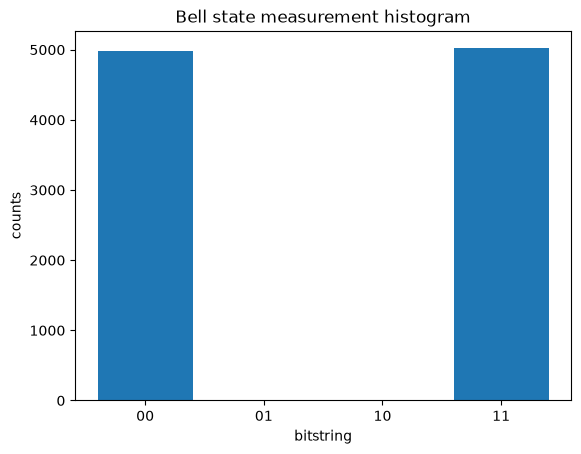

In [20]:
import matplotlib.pyplot as plt

BITSTR = ["00","01","10","11"]

def sample_bitstrings(psi: np.ndarray, shots: int = 10_000, seed: int = 7):
    rng = np.random.default_rng(seed)
    probs = np.abs(psi)**2
    idx = rng.choice(4, size=shots, p=probs)
    return idx

# Sample from Bell state
shots = 10_000
idx = sample_bitstrings(psi_bell, shots=shots)

# Make histogram
counts = {b: int(np.sum(idx == i)) for i, b in enumerate(BITSTR)}
print(counts)
plt.bar(counts.keys(), counts.values())
plt.xlabel("bitstring"); plt.ylabel("counts"); plt.title("Bell state measurement histogram")
plt.show()

**Task 1.4 — Do the counts match expectations within sampling error?**

Yes. The observed counts are:

| Bitstring | Theoretical probability | Expected count | Observed count |
| --- | ---: | ---: | ---: |
| 00 | 0.5 | 5000 | 4983 |
| 01 | 0 | 0 | 0 |
| 10 | 0 | 0 | 0 |
| 11 | 0.5 | 5000 | 5017 |

The counts for `00` and `11` are close to the expected equal split. Small deviations are normal when sampling a finite number of measurements. Outcomes `01` and `10` are absent, as expected.

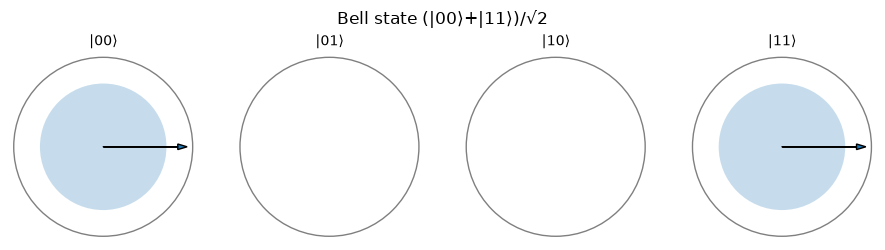

In [21]:
def sv_from_circ(circ: QuantumCircuit) -> np.ndarray:
    sv = Statevector(circ)
    return np.asarray(sv, dtype=np.complex128)

class QubitSystem:
    def __init__(self, statevector: np.ndarray, label: str = "Qubit System"):
        self.label = label
        self.set_statevector(statevector)

    def set_statevector(self, statevector: np.ndarray):
        sv = np.asarray(statevector, dtype=np.complex128)
        if sv.ndim != 1:
            raise ValueError("Statevector must be 1D.")
        n_states = sv.size
        if n_states == 0 or not np.all(np.isfinite(sv)):
            raise ValueError("Statevector must be nonempty and finite.")
        n_qubits = int(round(math.log2(n_states)))
        if 2**n_qubits != n_states:
            raise ValueError("Length must be a power of 2.")
        # Defensive normalization (harmless if already normalized)
        norm = np.linalg.norm(sv)
        if norm == 0 or not np.isfinite(norm):
            raise ValueError("Statevector must have a finite, nonzero norm.")
        sv = sv / norm

        self.n_qubits = n_qubits
        self.n_states = n_states
        self.amps  = sv
        self.prob  = np.abs(sv)**2
        self.phase = np.angle(sv)

    def viz_circle(self, max_cols: int = 8, figsize_scale: float = 2.3):
        cols = max(1, min(max_cols, self.n_states))
        rows = int(math.ceil(self.n_states / cols))

        fig, axes = plt.subplots(
            rows, cols, squeeze=False,
            figsize=(cols*figsize_scale, rows*(figsize_scale+0.2))
        )

        def bitstr(i: int, n: int) -> str:
            return format(i, f"0{n}b")

        for idx in range(rows * cols):
            r, c = divmod(idx, cols)
            ax = axes[r, c]
            ax.set_aspect("equal")
            ax.set_xlim(0, 1); ax.set_ylim(0, 1)
            ax.axis("off")

            if idx >= self.n_states:
                ax.set_visible(False)
                continue

            # Outer reference circle
            ax.add_patch(plt.Circle((0.5, 0.5), 0.48, fill=False, lw=1.0, alpha=0.5))

            # Filled disk: radius ∝ sqrt(probability) so area ∝ probability
            radius = 0.48 * np.sqrt(self.prob[idx])
            ax.add_patch(plt.Circle((0.5, 0.5), radius, alpha=0.25))

            # Zero amplitudes have no defined phase.
            if self.prob[idx] > 0:
                angle = self.phase[idx]
                L = 0.45
                x2 = 0.5 + L * np.cos(angle)
                y2 = 0.5 + L * np.sin(angle)
                ax.arrow(0.5, 0.5, x2 - 0.5, y2 - 0.5,
                         head_width=0.03, head_length=0.05, length_includes_head=True)

            ax.set_title(f"|{bitstr(idx, self.n_qubits)}⟩", fontsize=10)

        fig.suptitle(self.label, fontsize=12)
        plt.tight_layout()
        plt.show()

QubitSystem(psi_bell, label="Bell state (|00⟩+|11⟩)/√2").viz_circle()

**Task 1.4:  How does the circle plot show two dominant components |00> and |11> and their relative phase?**

Each position represents one computational basis state. In `viz_circle`, the filled radius is proportional to $\sqrt{p_i}=|\psi_i|$, so the filled area is proportional to the probability $p_i$. The circles for $|00\rangle$ and $|11\rangle$ therefore have equal filled area, each representing probability $1/2$. The positions for $|01\rangle$ and $|10\rangle$ have zero filled area.
The arrows encode $\arg(\psi_i)$. Both nonzero Bell amplitudes are real and positive, so both arrows point to the right: their relative phase is zero. Zero amplitudes have no defined phase and are drawn without arrows. A global phase would rotate both nonzero arrows by the same amount without changing their relative phase or measurement probabilities. 

## 6. SWAP test: setup — Task 2

The objective is to infer the fidelity between two normalized pure one-qubit states and compare it with the direct inner product:

$$
F=|\langle\psi|\phi\rangle|^2,\qquad
P(1)=\frac{1-F}{2},\qquad F=1-2P(1).
$$

In [22]:
def expand_1q_n(U: np.ndarray, t: int, n: int) -> np.ndarray:
    op = np.array([[1]], dtype=U.dtype)
    for q in range(n):
        op = np.kron(op, U if q == t else I2)
    return op

# Apply CSWAP, with ancilla as control
P0 = np.array([[1,0],[0,0]], dtype=DTYPE)  # |0><0| on ancilla
P1 = np.array([[0,0],[0,1]], dtype=DTYPE)  # |1><1| on ancilla
SWAP_A0_B0 = np.array([
    [1,0,0,0],
    [0,0,1,0],
    [0,1,0,0],
    [0,0,0,1]
], dtype=DTYPE)  # SWAP on A0 and B0
CSWAP = (np.kron(P0, np.eye(4)) + np.kron(P1, SWAP_A0_B0)) # CSWAP with ancilla as control

In [23]:
psi = np.array([1, 0], dtype=DTYPE)
phi = np.array([0, 1], dtype=DTYPE)
assert np.isclose(np.linalg.norm(psi), 1.0)
assert np.isclose(np.linalg.norm(phi), 1.0)
init = np.kron(np.array([1,0], dtype=DTYPE), np.kron(psi, phi))  
U_Ho = expand_1q_n(H, t=0, n=3)
state = U_Ho @ init
state = CSWAP @ state
state = U_Ho @ state

probs = np.abs(state)**2
prob_1 = probs[4:].sum()   # indices with output=1
F_hat = 1 - 2*prob_1
F_exact = float(np.abs(np.vdot(psi/np.linalg.norm(psi), phi/np.linalg.norm(phi)))**2)

assert np.isclose(np.sum(np.abs(state)**2), 1.0)
assert np.isclose(F_hat, F_exact)
print(F_hat, F_exact)

######################
psi = np.array([1, 0], dtype=DTYPE)
phi = np.array([1, 0], dtype=DTYPE)
assert np.isclose(np.linalg.norm(psi), 1.0)
assert np.isclose(np.linalg.norm(phi), 1.0)

init = np.kron(np.array([1,0], dtype=DTYPE), np.kron(psi, phi))  
U_Ho = expand_1q_n(H, t=0, n=3)
state = U_Ho @ init
state = CSWAP @ state
state = U_Ho @ state

probs = np.abs(state)**2
prob_1 = probs[4:].sum()   
F_hat = 1 - 2*prob_1
F_exact = float(np.abs(np.vdot(psi/np.linalg.norm(psi), phi/np.linalg.norm(phi)))**2)
assert np.isclose(np.sum(np.abs(state)**2), 1.0)
assert np.isclose(F_hat, F_exact)
print(F_hat, F_exact)

######################
psi = np.array([1, 1], dtype=DTYPE) / np.sqrt(2)
phi = np.array([1, 0], dtype=DTYPE)
assert np.isclose(np.linalg.norm(psi), 1.0)
assert np.isclose(np.linalg.norm(phi), 1.0)

init = np.kron(np.array([1,0], dtype=DTYPE), np.kron(psi, phi)) 
U_Ho = expand_1q_n(H, t=0, n=3)
state = U_Ho @ init
state = CSWAP @ state
state = U_Ho @ state

probs = np.abs(state)**2
prob_1 = probs[4:].sum()  
F_hat = 1 - 2*prob_1
F_exact = float(np.abs(np.vdot(psi/np.linalg.norm(psi), phi/np.linalg.norm(phi)))**2)
assert np.isclose(np.sum(np.abs(state)**2), 1.0)
assert np.isclose(F_hat, F_exact)
print(F_hat, F_exact)

4.440892098500626e-16 0.0
1.0 1.0
0.5000000000000002 0.5000000000000001


**Task 2: Report F_hat versus F_exact for at least three pairs.**

| Input psi | Input phi | P(output=1) | F_hat from SWAP test | F_exact from inner product |
| --- | --- | ---: | ---: | ---: |
| $\lvert 0\rangle$ | $\lvert 1\rangle$ | 0.5 | 0 | 0 |
| $\lvert 0\rangle$ | $\lvert 0\rangle$ | 0 | 1 | 1 |
| $\lvert +\rangle$ | $\lvert 0\rangle$ | 0.25 | 0.5 | 0.5 |

Values are rounded for readability. In the first case the printed `F_hat` is about $4.44\times10^{-16}$, which is numerical roundoff around zero. `np.vdot` conjugates the first vector, giving the correct complex inner product. The input and final-state normalization checks pass, as do all three fidelity comparisons.

**How does the output bit encode overlap?**

After H–CSWAP–H, the joint state is

$$
\frac{1}{2}|0\rangle\bigl(|\psi\rangle|\phi\rangle+|\phi\rangle|\psi\rangle\bigr)
+\frac{1}{2}|1\rangle\bigl(|\psi\rangle|\phi\rangle-|\phi\rangle|\psi\rangle\bigr)
$$

The probability of measuring 1 on the output qubit is $P(1)=(1-F)/2$. The larger the overlap, the less likely we are to measure 1. For the three pairs above, identical inputs give $P(1)=0$, orthogonal inputs give $P(1)=1/2$, and the partially overlapping states $|+\rangle$ and $|0\rangle$ give $P(1)=1/4$. A single measurement of 0 does not prove that the inputs are identical, because different states can also give this result.

## Bonus 1: Basis-state comparison (Task B.1)

### Short Introduction

The reference register is prepared in $|5\rangle = |101\rangle$, while the test register is prepared in a computational basis state $|k\rangle$, with $k \in \{0,\ldots,7\}$. 

We first implement the standard multiqubit SWAP test using one shared output ancilla, and then investigate an alternative pairwise control distribution.

### Solution: Multiqubit SWAP test

In [24]:
def fidelity(u, v):
    u = u / np.linalg.norm(u)
    v = v / np.linalg.norm(v)
    return float(np.abs(np.vdot(u, v))**2)


def prepare_basis_state(circuit, register, k):
    # Qiskit index 0 is the least significant bit.
    for i in range(len(register)):
        if (k >> i) & 1:
            circuit.x(register[i])


def append_controlled_swap(circuit, control, qubit_a, qubit_b):
    circuit.ccx(control, qubit_a, qubit_b)
    circuit.ccx(control, qubit_b, qubit_a)
    circuit.ccx(control, qubit_a, qubit_b)


def build_swap_test(k, superpose_test=False):
    n = 3
    reference_k = 5  # |101>
    reference = QuantumRegister(n, "reference")
    test = QuantumRegister(n, "test")
    output = QuantumRegister(1, "output")
    result = ClassicalRegister(1, "result")
    circuit = QuantumCircuit(reference, test, output, result)

    prepare_basis_state(circuit, reference, reference_k)
    prepare_basis_state(circuit, test, k)

    if superpose_test:      # Used later for B2
        circuit.h(test[0])  # Used later for B2

    circuit.h(output[0])
    for i in range(n):
        append_controlled_swap(circuit, output[0], reference[i], test[i])
    circuit.h(output[0])
    circuit.measure(output[0], result[0])
    return circuit


#### Sanity checks and validation

In [ ]:
# For the basis states in B.1, the expected fidelity is either 0 or 1.
def check_basis_fidelity(estimated, expected, shots):
    assert expected in (0, 1)
    if expected == 1:
        assert estimated == 1  # Identical inputs always give output 0.
    else:
        # Orthogonal inputs: standard error of F_hat is 1/sqrt(shots).
        assert abs(estimated) <= 5 / np.sqrt(shots)


# Correctness check
for k in range(8):
    exact_circuit = build_swap_test(k).remove_final_measurements(inplace=False)
    output_index = exact_circuit.find_bit(exact_circuit.qregs[2][0]).index
    exact_p1 = Statevector.from_instruction(exact_circuit).probabilities([output_index])[1]
    assert np.isclose(1 - 2 * exact_p1, int(k == 5), atol=1e-12)

simulator = AerSimulator()
shots_bonus = 10_000
for k in [5, 0]:
    circuit = transpile(build_swap_test(k), simulator)
    counts = simulator.run(circuit, shots=shots_bonus, seed_simulator=7).result().get_counts()
    p1 = counts.get("1", 0) / shots_bonus
    estimated = 1 - 2 * p1
    expected = 1 if k == 5 else 0
    print("k =", k, "Estimated fidelity:", round(estimated, 3), "Expected:", expected)
    check_basis_fidelity(estimated, expected, shots_bonus)

k = 5 Estimated fidelity: 1.0 Expected: 1
k = 0 Estimated fidelity: 0.002 Expected: 0


**Remember to perform sanity checks of your code! Identical states $|101\rangle$ and $|101\rangle$ should yield $F=1$; different basis states (e.g., $|101\rangle$ vs $|000\rangle$) should yield $F=0$.**

The exact checks pass for all eight basis states. Sampling with 10,000 shots gives:

| Test state | True fidelity | Estimated fidelity |
| --- | ---: | ---: |
| $\lvert101\rangle$ | 1 | 1.000 |
| $\lvert000\rangle$ | 0 | 0.002 |

The small deviation from zero is consistent with shot noise.


#### Circuit diagram

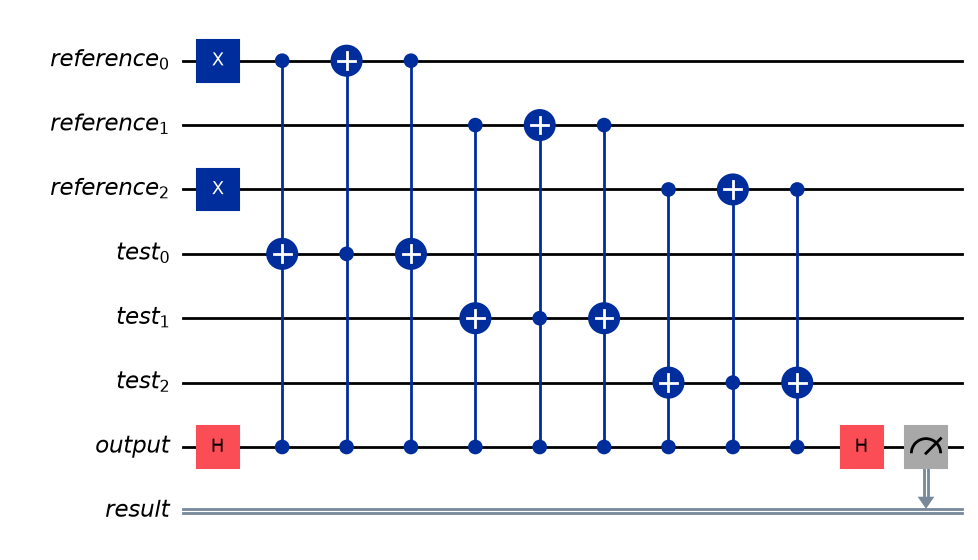

In [26]:
# Circuit diagram of the standard multiqubit SWAP test.
# k = 0 is used only as an illustrative example against the reference |101>.

example_swap_circuit = build_swap_test(k=0)

example_swap_circuit.draw(output="mpl", fold=-1, cregbundle=False)

#### Design discussion

The circuit uses a single output qubit as a shared control for all three matched pairs $(R_i,T_i)$. After preparing the reference register in $|5\rangle=|101\rangle$ and the test register in $|k\rangle$, a Hadamard gate is applied to the output qubit. The controlled exchange is then performed independently on each of the three matched pairs, but all exchanges are conditioned on the same output qubit. Finally, a second Hadamard is applied to the output qubit and only this qubit is measured. Its measurement probability is used to estimate the global fidelity according to the required convention
$$
\hat F = 1 - 2\hat P(\mathrm{output}=1).
$$

Each controlled exchange was implemented by starting from the three CNOT decomposition of a SWAP operation and adding the output qubit as an additional control. Since there are three matched qubit pairs, the complete exchange requires $3\times3=9$ CCX gates. The circuit also uses two Hadamard gates and one measurement, for a total of seven qubits: three reference qubits, three test qubits, and one output ancilla.

This implementation is intentionally simple rather than optimal for resources. One limitation is that the same output qubit participates in every controlled exchange, so the nine CCX operations cannot all be executed in parallel at the logical level. This can increase circuit depth compared with a design using independent output ancillas

#### Evaluation protocol

**Run with AerSimulator at several shots values (e.g., 1k, 2k, 4k). From get_counts(), compute $\hat P(1)$ and report the estimated fidelity $\hat F$.**

We run AerSimulator with 1,000, 2,000, and 4,000 shots. For N shots, $\hat P(1)=\mathrm{counts.get}(\text{"1"},0)/N$ and $\hat F=1-2\hat P(1)$. Results are reported below.

In [27]:
shots_values = [1_000, 2_000, 4_000]
repetitions = 30
rng = np.random.default_rng(34)
seed = 7_000

print("Shots | Case | Mean fidelity | Standard error")
for shots in shots_values:
    for case in ["Positive", "Negative"]:
        fidelities = []
        for repeat in range(repetitions):
            k = 5
            if case == "Negative":
                k = int(rng.choice([0, 1, 2, 3, 4, 6, 7]))
            circuit = transpile(build_swap_test(k), simulator, seed_transpiler=7)
            counts = simulator.run(
                circuit, shots=shots, seed_simulator=seed
            ).result().get_counts()
            seed += 1
            p1 = counts.get("1", 0) / shots
            fidelities.append(1 - 2 * p1)

        mean = np.mean(fidelities)
        error = np.std(fidelities, ddof=1) / np.sqrt(repetitions)
        print(shots, case, round(mean, 6), round(error, 6), sep=" | ")


Shots | Case | Mean fidelity | Standard error
1000 | Positive | 1.0 | 0.0
1000 | Negative | -0.008333 | 0.005605
2000 | Positive | 1.0 | 0.0
2000 | Negative | -0.0021 | 0.004297
4000 | Positive | 1.0 | 0.0
4000 | Negative | 0.001717 | 0.003098


**Run your circuit and report estimated fidelities for both positives (k=5) and negatives (k≠5). Report mean and standard error (not the standard deviation) for the two cases in a table.**

The result are listed in the result of the previous code block.

Each row summarizes 30 independent trials. Positives use k=5, negatives are drawn uniformly from the other seven basis states. The standard error is the sample standard deviation divided by the square root of 30. Different simulator seeds are used for each trial.


#### Analysis

**How does the true fidelity differ from the estimated fidelity when we compare identical states? What is the effect of shot noise?**

Identical states have $F=1$, $P(0)=1$, and $P(1)=0$. Every shot gives 0, so the estimated fidelity is always 1 and its standard error is 0. There is no shot noise for this deterministic outcome in the ideal simulator.


**How does the true fidelity differ from the estimated fidelity when we compare different states? What is the effect of shot noise?**

Different basis states have $F=0$ and $P(0)=P(1)=1/2$. Finite sampling makes $\hat F$ fluctuate around zero.


**Assuming that the test state is in some unknown three-qubit computational basis state (while the reference state is still in the known state $|101\rangle$) propose a strategy for how you could determine if the test state is in fact equal to the reference state or not.**

Repeat the SWAP test against $|101\rangle$, using fresh preparations of the same unknown test state. Decide from the output measurements without using k: equality gives F=1, while every other basis state gives F=0. The test detects equality but cannot identify which different basis state was supplied.


**Would you need to sample multiple times from the quantum circuit, or would a single sample suffice? Remember that we assume that only the reference state is known.**

A single 1 proves that the states differ in the ideal circuit. A single 0 is inconclusive because different basis states also give 0 with probability 1/2. Repeated independent tests support an equality decision with a chosen error tolerance, but finitely many zeros cannot prove equality with certainty.


**Based on the sample outcome(s), what would be your "decision rule" to determine if the test state is the same as the reference state or not?**

If any of m independent outputs is 1, declare the states different, if all are 0, declare them equal. For different states, the probability of falsely declaring equality is $2^{-m}$; for identical states, the false-negative probability is zero in the ideal circuit. With m=10, the false-positive probability is about 0.098%. For a target error $\epsilon$, choose $m\ge\lceil\log_2(1/\epsilon)\rceil$.


### Alternative design: Parallel pairwise SWAP tests

As an additional experiment, we replace the shared output ancilla with one output qubit for each matched pair $(R_i,T_i)$. 

This produces three local SWAP test measurements rather than measuring the global three qubit overlap directly.

In [28]:
N_QUBITS = 3
REFERENCE_K = 5  # |101>

# Build n independent pairwise SWAP tests.
def build_parallel_swap_tests(k, n=N_QUBITS, reference_k=REFERENCE_K):
    reference = QuantumRegister(n, "reference")
    test = QuantumRegister(n, "test")
    output = QuantumRegister(n, "output")
    result = ClassicalRegister(n, "result")

    circuit = QuantumCircuit(reference, test, output, result)

    prepare_basis_state(circuit, reference, reference_k)
    prepare_basis_state(circuit, test, k)

    # One independent SWAP test for each matched qubit pair.
    for i in range(n):
        circuit.h(output[i])
        append_controlled_swap(circuit, output[i], reference[i], test[i])
        circuit.h(output[i])
        circuit.measure(output[i], result[i])

    return circuit

# Estimate output and corresponding local fidelity
def estimate_local_fidelities(counts, n=N_QUBITS):
    total_shots = sum(counts.values())
    count_ones = np.zeros(n, dtype=int)

    for bitstring, count in counts.items():
        # Qiskit prints classical bits with the highest index on the left.
        # Reversing gives bits[i] <-> result[i].
        bits = bitstring.replace(" ", "")[::-1]

        for i, bit in enumerate(bits):
            if bit == "1":
                count_ones[i] += count

    p1 = count_ones / total_shots
    local_fidelity = 1 - 2 * p1

    return p1, local_fidelity

# Fidelities for computational basis states
def expected_local_fidelities(k, n=N_QUBITS, reference_k=REFERENCE_K):
    return np.array(
        [float(((reference_k >> i) & 1) == ((k >> i) & 1)) for i in range(n)]
    )

#### Circuit diagram

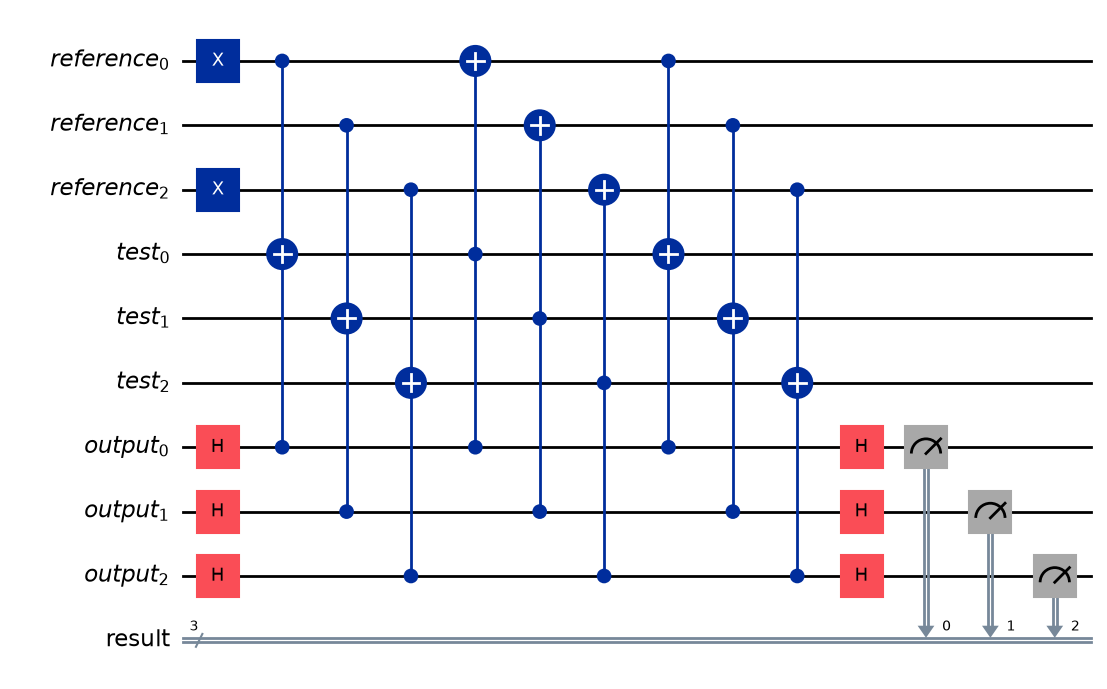

In [29]:
example_parallel_circuit = build_parallel_swap_tests(k=0)
example_parallel_circuit.draw("mpl")

#### Sanity checks and validation

As in the standard circuit, we check the exact output probabilities against the expected fidelities, then check estimates from 10,000 shots. Here the checks apply separately to each of the three output ancillas. Both implementations use `check_basis_fidelity`: identical basis inputs must give fidelity 1 exactly, while orthogonal inputs may fluctuate around 0 within five standard errors. The product of sampled local estimates remains a diagnostic for these product states.


In [ ]:
simulator = AerSimulator()

SHOTS = 10_000
SEED = 7

print(f"Reference state: |{REFERENCE_K:03b}>")
print()

for k in range(2**N_QUBITS):
    circuit = build_parallel_swap_tests(k)
    exact_circuit = circuit.remove_final_measurements(inplace=False)
    exact_state = Statevector.from_instruction(exact_circuit)
    compiled = transpile(circuit, simulator)

    counts = simulator.run(
        compiled,
        shots=SHOTS,
        seed_simulator=SEED
    ).result().get_counts()

    p1, local_fidelity = estimate_local_fidelities(counts)
    expected_local = expected_local_fidelities(k)
    local_product = np.prod(local_fidelity)
    exact_global = float(k == REFERENCE_K)

    for i in range(N_QUBITS):
        # Exact check of each output ancilla, as in the standard circuit.
        output_index = circuit.find_bit(circuit.qregs[2][i]).index
        exact_p1 = exact_state.probabilities([output_index])[1]
        assert np.isclose(1 - 2 * exact_p1, expected_local[i], atol=1e-12)
        check_basis_fidelity(local_fidelity[i], expected_local[i], SHOTS)

    print(
        f"k = {k} (|{k:03b}>) | "
        f"F0 = {local_fidelity[0]: .3f}, "
        f"F1 = {local_fidelity[1]: .3f}, "
        f"F2 = {local_fidelity[2]: .3f} | "
        f"product(local estimates) = {local_product: .3f} | "
        f"exact global F = {exact_global:.0f}"
    )

Reference state: |101>

k = 0 (|000>) | F0 =  0.003, F1 =  1.000, F2 =  0.002 | product(local estimates) =  0.000 | exact global F = 0
k = 1 (|001>) | F0 =  1.000, F1 =  1.000, F2 =  0.002 | product(local estimates) =  0.002 | exact global F = 0
k = 2 (|010>) | F0 = -0.012, F1 =  0.003, F2 =  0.002 | product(local estimates) = -0.000 | exact global F = 0
k = 3 (|011>) | F0 =  1.000, F1 =  0.003, F2 =  0.002 | product(local estimates) =  0.000 | exact global F = 0
k = 4 (|100>) | F0 =  0.002, F1 =  1.000, F2 =  1.000 | product(local estimates) =  0.002 | exact global F = 0
k = 5 (|101>) | F0 =  1.000, F1 =  1.000, F2 =  1.000 | product(local estimates) =  1.000 | exact global F = 1
k = 6 (|110>) | F0 =  0.003, F1 =  0.002, F2 =  1.000 | product(local estimates) =  0.000 | exact global F = 0
k = 7 (|111>) | F0 =  1.000, F1 =  0.002, F2 =  1.000 | product(local estimates) =  0.002 | exact global F = 0


#### Design discussion 

We tested a distributed control architecture in which each pair $(R_i,T_i)$ has its own output ancilla. Each ancilla undergoes its own H controlled exchange H sequence and is measured independently. With the chosen exchange decomposition, each pair requires three CCX gates. The complete parallel circuit therefore uses 9 qubits, 9 CCX gates, 6 Hadamard gates, and 3 measurements. In comparison, the single output implementation uses 7 qubits, the same 9 CCX gates, only 2 Hadamard gates, and one measurement.

The main advantage of the parallel design is that the three controlled exchanges act on disjoint sets of qubits. At the logical level, the three first CCX gates can therefore be executed in parallel, followed by the three second CCX gates and then the three third CCX gates. This trades two additional ancilla qubits for potentially smaller circuit depth. It also provides more information than the single output circuit: the three estimated fidelities identify which individual qubit pairs agree or disagree. For example, comparing $|101\rangle$ with $|100\rangle$ gives approximately $F_0=0$, $F_1=1$, and $F_2=1$, revealing that only the least significant pair differs. The actual transpiled depth on physical hardware would, however, depend on the native gate set, connectivity, and decomposition of the CCX gates, so the logical depth advantage should not be interpreted as a hardware independent result.

A limitation is that these three quantities are local fidelities, not a direct measurement of the global three qubit fidelity. For the computational basis states used in Task B.1, both registers are product states, so
$$
F_{\mathrm{global}} = F_0F_1F_2.
$$
Therefore, in this particular experiment the local results are sufficient to recover the same exact global comparison: all three local fidelities are one only for $k=5$, while at least one of them is zero for every $k\neq5$. However, this factorization cannot in general be assumed for arbitrary multiqubit states, especially entangled states. For this reason, we keep the single output multiqubit SWAP test as the main implementation required by the task and treat the parallel circuit as an alternative design used to study resource and information trade offs.

The small positive or negative values observed around zero for mismatching pairs are caused by finite shot sampling. For a mismatching computational basis pair, the exact probabilities are $P(0)=P(1)=1/2$, so the estimator
$$
\hat F_i = 1-2\hat P_i(1)
$$
fluctuates around zero. A slightly negative estimated value is therefore a sampling artifact rather than a negative physical fidelity. Equal pairs instead have $P(1)=0$, so in the ideal simulator their estimated fidelity remains exactly one even with a finite number of shots.

## Bonus 2: Introducing Superposition (Task B.2)

### Modification and circuit design

The reference remains $|101\rangle$. We prepare the test register in $|k\rangle$ and apply H to `test[0]`, the **least significant qubit** in Qiskit. Thus, writing $k=b_2b_1b_0$,

$$
|t_k\rangle=|b_2b_1\rangle\otimes\frac{|0\rangle+(-1)^{b_0}|1\rangle}{\sqrt{2}}.
$$

The circuit still uses 7 qubits and 9 CCX gates, with no explicit two-qubit gates in the exchange. Preparation adds one H, making 3 H gates in total. There is no final X on the output, so $\hat F=1-2\hat P(1)$.

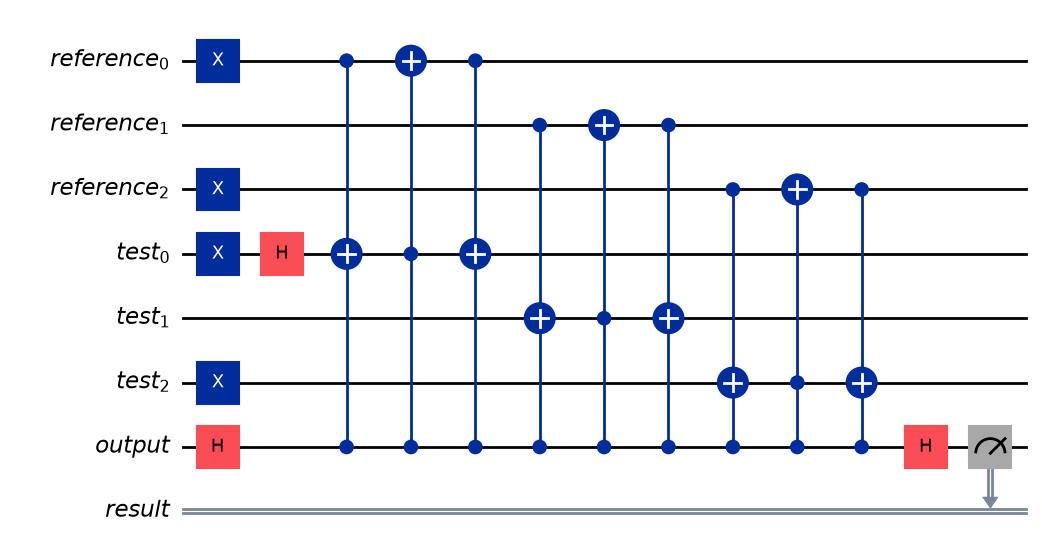

In [31]:
example_b2_circuit = build_swap_test(k=5, superpose_test=True)
example_b2_circuit.draw(output="mpl", fold=-1, cregbundle=False)

### Exact fidelities and sanity checks

Before sampling, we compare the exact ancilla probability with a direct inner product for all eight inputs. The independent NumPy preparation uses $I\otimes I\otimes H$, consistent with H acting on the least significant bit. We also check the prepared registers themselves, so accidentally changing the reference instead of the test cannot pass merely because the final overlap is the same.

In [32]:
from IPython.display import Markdown, display

b2_reference = np.eye(8, dtype=DTYPE)[5]
b2_prepare_h = np.kron(np.eye(4, dtype=DTYPE), H)
b2_expected = np.array([0, 0, 0, 0, 0.5, 0.5, 0, 0], dtype=float)
b2_exact = {}
b2_exact_rows = []

for k in range(8):
    test_state = b2_prepare_h @ np.eye(8, dtype=DTYPE)[k]
    direct_fidelity = fidelity(b2_reference, test_state)
    assert np.isclose(np.linalg.norm(test_state), 1.0)
    assert np.isclose(direct_fidelity, b2_expected[k], atol=1e-12)

    circuit = build_swap_test(k, superpose_test=True)
    # All operations before the first H on output belong to preparation.
    preparation = QuantumCircuit(7)
    for instruction in circuit.data:
        qubits = [circuit.find_bit(q).index for q in instruction.qubits]
        if 6 in qubits:
            break
        preparation.append(instruction.operation, qubits)
    # Qiskit statevector order: |output test_2 test_1 test_0 ref_2 ref_1 ref_0>.
    expected_preparation = np.kron([1, 0], np.kron(test_state, b2_reference))
    assert np.allclose(Statevector.from_instruction(preparation).data,
                       expected_preparation, atol=1e-12)

    exact_circuit = circuit.remove_final_measurements(inplace=False)
    exact_state = Statevector.from_instruction(exact_circuit)
    output_index = exact_circuit.find_bit(exact_circuit.qregs[2][0]).index
    exact_p1 = float(exact_state.probabilities([output_index])[1])
    assert np.isclose(np.linalg.norm(exact_state.data), 1.0)
    assert np.isclose(1 - 2 * exact_p1, direct_fidelity, atol=1e-12)
    b2_exact[k] = direct_fidelity
    b2_exact_rows.append(
        f"| {k} | {k:03b} | {'Positive' if k == 5 else 'Negative'} | "
        f"{direct_fidelity:.3f} | {exact_p1:.3f} |"
    )

    # Regression check: enabling B.2 must not change the default B.1 circuit.
    basis_circuit = build_swap_test(k).remove_final_measurements(inplace=False)
    basis_p1 = Statevector.from_instruction(basis_circuit).probabilities([6])[1]
    assert np.isclose(1 - 2 * basis_p1, float(k == 5), atol=1e-12)

display(Markdown(
    "| k | Initial test bitstring | Case | Exact fidelity | Exact P(1) |\n"
    "| ---: | --- | --- | ---: | ---: |\n" + "\n".join(b2_exact_rows)
))
print("All eight preparation, normalization, fidelity, and B.1 regression checks passed.")

| k | Initial test bitstring | Case | Exact fidelity | Exact P(1) |
| ---: | --- | --- | ---: | ---: |
| 0 | 000 | Negative | 0.000 | 0.500 |
| 1 | 001 | Negative | 0.000 | 0.500 |
| 2 | 010 | Negative | 0.000 | 0.500 |
| 3 | 011 | Negative | 0.000 | 0.500 |
| 4 | 100 | Negative | 0.500 | 0.250 |
| 5 | 101 | Positive | 0.500 | 0.250 |
| 6 | 110 | Negative | 0.000 | 0.500 |
| 7 | 111 | Negative | 0.000 | 0.500 |

All eight preparation, normalization, fidelity, and B.1 regression checks passed.


### Rerun and compare

**Rerun the full pipeline and report estimated fidelities for positives (k=5) and negatives (k!=5).**

We use AerSimulator with 1,000, 2,000, and 4,000 shots, with 30 independent trials per case. The main negative group draws k uniformly from the seven values other than 5. We additionally run two separate diagnostic groups: k=4 and the six remaining negatives, so the overlapping negative is visible rather than hidden in an average.

For each run, $\hat P(1)=n_1/N$ and $\hat F=1-2\hat P(1)$. Each table reports the sample mean and its **standard error**, $s/\sqrt{30}$, where s is the sample standard deviation across trials. Seeds are fixed for reproducibility; each run uses a distinct simulator seed. The diagnostic runs are additional experiments, not a partition of the main negative sample.

In [33]:
b2_shots_values = [1_000, 2_000, 4_000]
b2_repetitions = 30
b2_rng = np.random.default_rng(43)
b2_simulator = AerSimulator()
b2_compiled = {
    k: transpile(build_swap_test(k, superpose_test=True), b2_simulator,
                 seed_transpiler=7)
    for k in range(8)
}
b2_cases = {
    "Positive (k=5)": [5],
    "Negative (k!=5)": [0, 1, 2, 3, 4, 6, 7],
    "Negative with overlap (k=4)": [4],
    "Other negatives (k!=4,5)": [0, 1, 2, 3, 6, 7],
}
b2_trials = []
b2_summary = []

for shots in b2_shots_values:
    for case, candidates in b2_cases.items():
        estimates = []
        probabilities = []
        for repeat in range(b2_repetitions):
            k = int(b2_rng.choice(candidates))
            seed = 20_000 + len(b2_trials)
            counts = b2_simulator.run(
                b2_compiled[k], shots=shots, seed_simulator=seed
            ).result().get_counts()
            assert sum(counts.values()) == shots
            p1 = counts.get("1", 0) / shots
            estimated = 1 - 2 * p1
            # A generous shot-noise bound; exact correctness is checked above.
            assert abs(estimated - b2_exact[k]) <= 5 / np.sqrt(shots)
            probabilities.append(p1)
            estimates.append(estimated)
            b2_trials.append({
                "shots": shots, "case": case, "k": k, "seed": seed,
                "counts": counts, "p1": p1, "fidelity": estimated,
            })
        b2_summary.append({
            "shots": shots, "case": case, "trials": b2_repetitions,
            "expected_fidelity": float(np.mean([b2_exact[k] for k in candidates])),
            "mean_p1": float(np.mean(probabilities)),
            "mean_fidelity": float(np.mean(estimates)),
            "standard_error": float(np.std(estimates, ddof=1)
                                    / np.sqrt(b2_repetitions)),
        })

for title, cases in [
    ("Main comparison", ["Positive (k=5)", "Negative (k!=5)"]),
    ("Additional negative groups", ["Negative with overlap (k=4)",
                                    "Other negatives (k!=4,5)"]),
]:
    rows = [
        f"| {row['shots']} | {row['case']} | {row['trials']} | "
        f"{row['expected_fidelity']:.6f} | {row['mean_p1']:.6f} | "
        f"{row['mean_fidelity']:.6f} | {row['standard_error']:.6f} |"
        for row in b2_summary if row['case'] in cases
    ]
    display(Markdown(
        f"**{title}**\n\n"
        "| Shots per trial | Case | Trials | Expected fidelity | Mean P(1) | "
        "Mean fidelity | Standard error |\n"
        "| ---: | --- | ---: | ---: | ---: | ---: | ---: |\n" + "\n".join(rows)
    ))

**Main comparison**

| Shots per trial | Case | Trials | Expected fidelity | Mean P(1) | Mean fidelity | Standard error |
| ---: | --- | ---: | ---: | ---: | ---: | ---: |
| 1000 | Positive (k=5) | 30 | 0.500000 | 0.247333 | 0.505333 | 0.005339 |
| 1000 | Negative (k!=5) | 30 | 0.071429 | 0.464300 | 0.071400 | 0.032404 |
| 2000 | Positive (k=5) | 30 | 0.500000 | 0.249067 | 0.501867 | 0.002378 |
| 2000 | Negative (k!=5) | 30 | 0.071429 | 0.432300 | 0.135400 | 0.041830 |
| 4000 | Positive (k=5) | 30 | 0.500000 | 0.251442 | 0.497117 | 0.002397 |
| 4000 | Negative (k!=5) | 30 | 0.071429 | 0.474892 | 0.050217 | 0.029282 |

**Additional negative groups**

| Shots per trial | Case | Trials | Expected fidelity | Mean P(1) | Mean fidelity | Standard error |
| ---: | --- | ---: | ---: | ---: | ---: | ---: |
| 1000 | Negative with overlap (k=4) | 30 | 0.500000 | 0.248500 | 0.503000 | 0.005280 |
| 1000 | Other negatives (k!=4,5) | 30 | 0.000000 | 0.502267 | -0.004533 | 0.007481 |
| 2000 | Negative with overlap (k=4) | 30 | 0.500000 | 0.247500 | 0.505000 | 0.003809 |
| 2000 | Other negatives (k!=4,5) | 30 | 0.000000 | 0.499967 | 0.000067 | 0.003614 |
| 4000 | Negative with overlap (k=4) | 30 | 0.500000 | 0.252700 | 0.494600 | 0.002266 |
| 4000 | Other negatives (k!=4,5) | 30 | 0.000000 | 0.499342 | 0.001317 | 0.003073 |

For the positive and k=4 groups, the true fidelity is 1/2, so P(1)=1/4. Unlike the positive case in B.1, these outputs now have shot noise. At fixed k the standard deviation of a single fidelity estimate is $2\sqrt{P(1)(1-P(1))/N}$: $\sqrt{3/(4N)}$ for k=4 or 5, and $1/\sqrt{N}$ for the other negatives. Increasing shots reduces this source of uncertainty, although an empirical standard error need not decrease monotonically in a finite experiment.

The expected fidelity of a uniformly selected negative is $(1/7)(1/2)=1/14$. Its reported standard error includes both shot noise and variation in the randomly selected k: different batches of 30 trials can contain different numbers of k=4. More shots per trial do not remove that second source of variation. Small negative fidelity estimates for the zero-overlap groups are sampling fluctuations of the estimator, not negative physical fidelities.

### Discussion

**Do some negatives (k!= 5) show larger estimated fidelity? If yes, explain why and relate this to overlap.**

Yes. The negative k=4 changes from zero fidelity in B.1 to true fidelity 1/2 in B.2, with sampled estimates near 1/2 in the diagnostic table. The other six negatives retain zero overlap with the reference and estimates near zero. Specifically,

$$
|t_4\rangle=\frac{|100\rangle+|101\rangle}{\sqrt2},\qquad
|t_5\rangle=\frac{|100\rangle-|101\rangle}{\sqrt2}.
$$

Both have an amplitude of magnitude $1/\sqrt2$ on the reference $|101\rangle$, hence fidelity $|\langle101|t_k\rangle|^2=1/2$. Their relative phases differ, but this comparison with a single computational-basis reference is insensitive to that difference. Superposition introduces overlap for k=4 and reduces the positive k=5 from F=1 to F=1/2; it does not increase fidelity for every negative.

**Would it still be possible to determine whether k=5 using the strategy proposed in B.1? Explain why or why not.**

No. In B.1, any output 1 rules out k=5, while m zeros support equality with false-positive probability $2^{-m}$. In B.2, even k=5 produces output 1 with probability 1/4. Moreover, k=4 and k=5 give the identical distribution P(0)=3/4, P(1)=1/4. No number of repetitions of this same test, using only its output and the fixed reference, can distinguish these two labels.

If we nevertheless apply the old rule, the probability of declaring k=5 is $(3/4)^m$ for both k=4 and k=5. The false-negative probability for the true positive is therefore $1-(3/4)^m$. With m=10, this is about 94.4%, whereas it was zero in ideal B.1. A threshold near F=1/2 could detect the set {4,5}, but could not tell its members apart. This limitation concerns the chosen SWAP-test comparison, not every possible measurement of the modified states.

**Reflection: what changed with superposition, and what concrete improvement would you try next?**

The SWAP test still estimates overlap correctly, as the direct inner-product checks confirm. However, after modifying only the test register, overlap no longer uniquely identifies the original positive label: one negative and the positive share the same fidelity. More shots improve precision but cannot resolve that ambiguity.

As a next experiment, we would apply the same H to the reference as well. Since H is unitary, $|\langle H_0 101|H_0 k\rangle|^2=|\langle101|k\rangle|^2$, restoring fidelity 1 for k=5 and 0 otherwise. We would validate those predictions with exact inner products and then repeat the sampled comparison. This is a proposed extension; the B.2 experiment above keeps the reference fixed as required.

## AI assistance disclosure

**Tool used:** OpenAI ChatGPT ; the specific model version is not recorded in this draft.

**Use by task:**

- **Task 1:** Review of the simulator, Bell-state results, visualizations, and clarity of the explanations.
- **Task 2:** Review of the SWAP-test implementation, fidelity comparisons, and interpretation of the output qubit.
- **Bonus B.1:** Review of the circuit, statistical results, and coverage of the assignment questions, plus assistance simplifying the sampling code and sharing preparation, controlled-SWAP helpers, and sanity checks between the circuit designs.
- **Bonus B.2:** Assistance with implementing the superposition experiment, adding validation and result tables, and revising the discussion of overlap and the decision rule.

**Interaction summary:** The main requests were to compare the notebook with the assignment, identify incomplete or unclear answers, check the saved circuit diagram, complete B.2, and draft this disclosure.

**Validation:** During the AI-assisted review, the code was rerun, existing assertions were checked, numerical results were compared with theoretical expectations, and plots and relevant Qiskit documentation were inspected. The circuit diagram output was subsequently corrected and checked. B.2 was checked against exact inner products for all eight inputs and rerun with multiple shot budgets; the default B.1 behavior was also checked.

*This draft summarizes the assistance documented so far and should be updated before submission to reflect any additional use and the final validation.*